# Разведывательный анализ данных (EDA)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams["figure.figsize"] = (8, 5)


## 1. Создадим пример датасета

In [4]:
data = pd.DataFrame({
    "age": np.random.normal(30, 5, 1000),
    "salary": np.random.normal(50000, 10000, 1000),
    "experience": np.random.randint(0, 15, 1000)
})

# Добавим пропуски
data.loc[np.random.choice(data.index, 50), "salary"] = np.nan

# Добавим выбросы
data.loc[np.random.choice(data.index, 5), "salary"] = 200000

data.head()


,age,salary,experience
0,26.703604,64081.135727,4
1,30.268207,65866.772406,12
2,24.458879,57652.028342,5
3,28.916827,49198.944006,5
4,33.536509,52560.831467,9


## 2. Первичный анализ

In [12]:
data.pivot_table(index='experience', columns='salary', aggfunc='count').head()

age                                            \
salary     17813.893295  22921.562846  24513.998764  24630.098762    
experience                                                           
0                    NaN           NaN           NaN           NaN   
1                    NaN           NaN           NaN           NaN   
2                    NaN           NaN           NaN           1.0   
3                    NaN           NaN           NaN           NaN   
4                    NaN           1.0           NaN           NaN   

                                                                    \
salary     26615.973631  27371.562114  27706.193297  28156.536473    
experience                                                           
0                    NaN           1.0           NaN           NaN   
1                    NaN           NaN           NaN           NaN   
2                    NaN           NaN           NaN           NaN   
3                    1.0           NaN           NaN           NaN   
4                    NaN           NaN           NaN           NaN   

                                        ...                              \
salary     28358.289274  28548.948144   ... 73480.882139  74144.667381    
experience                              ...                               
0                    NaN           1.0  ...           NaN           NaN   
1                    NaN           NaN  ...           1.0           1.0   
2                    NaN           NaN  ...           NaN           NaN   
3                    NaN           NaN  ...           NaN           NaN   
4                    NaN           NaN  ...           NaN           NaN   

                                                                    \
salary     75466.117470  75767.588267  76855.347094  78654.571259    
experience                                                           
0                    NaN           NaN           NaN           NaN   
1                    NaN           1.0           NaN           NaN   
2                    NaN           NaN           NaN           NaN   
3                    NaN           NaN           NaN           1.0   
4                    NaN           NaN           NaN           NaN   

                                                                    
salary     80067.944151  81241.844022  84178.400215  200000.000000  
experience                                                          
0                    NaN           NaN           NaN           NaN  
1                    NaN           NaN           NaN           NaN  
2                    NaN           NaN           NaN           NaN  
3                    NaN           NaN           NaN           NaN  
4                    NaN           NaN           NaN           2.0  

[5 rows x 948 columns]

In [ ]:
#data.info()
#data.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         1000 non-null   float64
 1   salary      952 non-null    float64
 2   experience  1000 non-null   int32  
dtypes: float64(2), int32(1)
memory usage: 19.7 KB


,age,salary,experience
count,1000.000000,952.000000,1000.000000
mean,29.873428,50206.836976,7.160000
std,5.116981,14704.104348,4.378307
min,13.995832,16509.890263,0.000000
25%,26.405215,42780.455701,3.000000
50%,30.043852,49455.298595,7.000000
75%,33.284417,56128.526783,11.000000
max,50.603661,200000.000000,14.000000


## 3. Работа с пропусками

In [4]:
data.isna()

,age,salary,experience
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
995,False,False,False
996,False,False,False
997,False,False,False
998,False,False,False


In [5]:
# Проверка пропусков
data.isna().sum()


age            0
salary        48
experience     0
dtype: int64

In [6]:
# Заполнение средним значением
data["salary_filled_mean"] = data["salary"].fillna(data["salary"].mean())

# Заполнение медианой
data["salary_filled_median"] = data["salary"].fillna(data["salary"].median())

data[["salary", "salary_filled_mean", "salary_filled_median"]].head()


,salary,salary_filled_mean,salary_filled_median
0,44683.486225,44683.486225,44683.486225
1,41051.194455,41051.194455,41051.194455
2,36764.723879,36764.723879,36764.723879
3,48084.361052,48084.361052,48084.361052
4,37107.060479,37107.060479,37107.060479



## Когда использовать среднее, медиану или удалять данные

Общее правило:

### Использовать СРЕДНЕЕ (mean), если:
- распределение близко к нормальному (p-value Шапиро–Уилка > 0.05)
- нет сильных выбросов
- асимметрия небольшая (skew ≈ 0)

### Использовать МЕДИАНУ (median), если:
- распределение скошено
- есть выбросы
- p-value Шапиро–Уилка < 0.05 (ненормальное распределение)

### УДАЛЯТЬ значения или столбец, если:
- доля пропусков очень большая (обычно > 30–40%)
- данные искажены или аномальны
- признак не имеет практической ценности

Ниже автоматически выводится рекомендация для каждого признака.


## 4. Поиск выбросов

In [7]:
# Метод IQR
Q1 = data["salary"].quantile(0.25)
Q3 = data["salary"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data["salary"] < lower_bound) | (data["salary"] > upper_bound)]

outliers.head(), len(outliers)


(           age         salary  experience  salary_filled_mean  \
 65   30.613758  200000.000000           6       200000.000000   
 115  24.972848   22737.732845           2        22737.732845   
 129  28.480836  200000.000000           7       200000.000000   
 221  30.627111   22123.529258          12        22123.529258   
 366  28.916890   21144.904870           2        21144.904870   
 
      salary_filled_median  
 65          200000.000000  
 115          22737.732845  
 129         200000.000000  
 221          22123.529258  
 366          21144.904870  ,
 15)

In [21]:
IQR

np.float64(13348.071082154565)

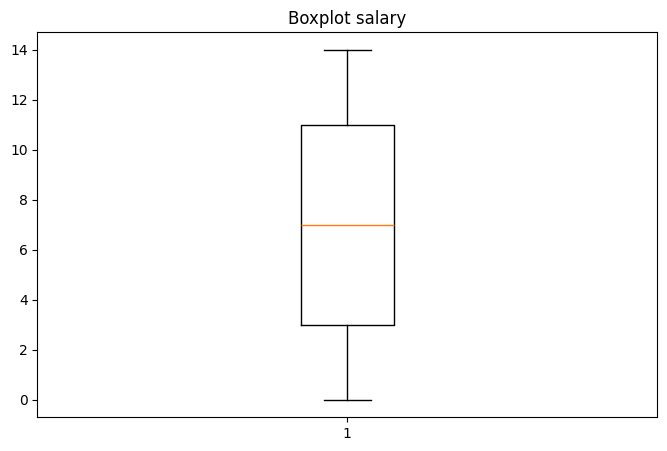

In [ ]:
# Визуализация через boxplot
plt.boxplot(data["experience"], data["salary"])
plt.title("Boxplot salary")
plt.show()


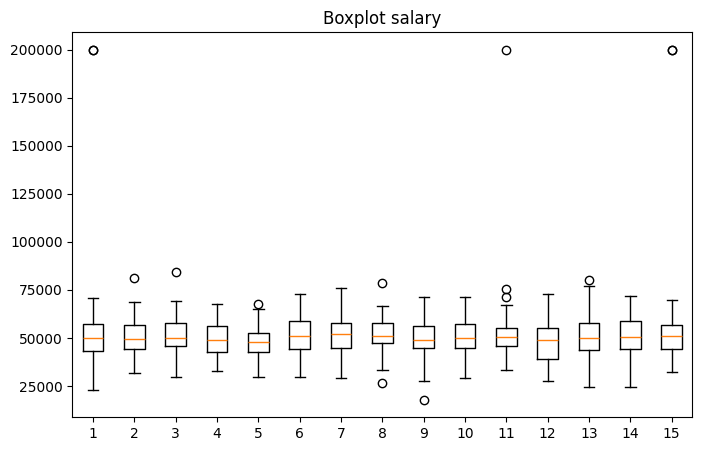

In [20]:
arr = []
for i in data['experience'].unique():
    arr.append(data.loc[data['experience'] == i]['salary'].dropna().values)
    
# Визуализация через boxplot
plt.boxplot(arr)
plt.title("Boxplot salary")
plt.show()


In [19]:
arr

[array([ 64081.13572658,  39745.19665933,  57096.4882239 ,  49301.00121407,
         54561.39220453,  22921.5628459 ,  69544.59180658,  35166.90918239,
         35705.65724084,  62038.8540849 ,  44086.66847999,  46918.4622446 ,
         43574.56024346,  50486.87821467,  50593.7076167 ,  69674.43282926,
         45135.98544386,  71018.86533525,  38944.59553011,  50527.48769324,
         44339.44176355,  58154.3194409 ,             nan,  66946.36052197,
         56196.81328248,  55064.43386854,  47240.57043641,  34607.87464765,
         55725.10655   ,  57296.48822695,  46822.7058508 ,  46330.91611102,
         51850.94296052,  39699.76695659,  41705.920338  ,  40149.44668889,
         43965.75761721,  31358.74246171,  49476.42871905,  43887.88451943,
         56655.73150138,  57230.46510256,  40681.42472211,  51599.91788706,
         53468.84428873,  42849.27568724,  52730.45989607,  62391.55150207,
        200000.        ,  35385.95990644,  58823.61749132,  47469.76915884,
         383

## 5. Проверка на нормальность

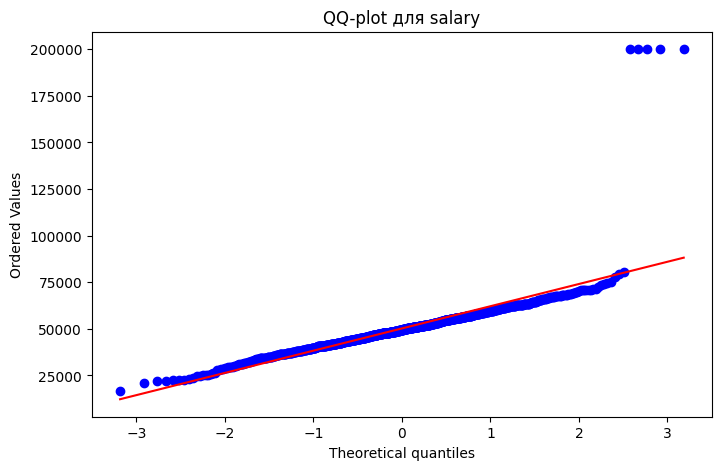

salary: p-value = 0.00000 -> НЕ нормальное распределение


In [ ]:
series = data['age'].dropna()

plt.figure()
stats.probplot(series, dist="norm", plot=plt)
plt.title(f"QQ-plot для {'age'}")
plt.show()

if len(series) <= 5000:
    stat, p_value = stats.shapiro(series)
    print(f"{'age'}: p-value = {p_value:.5f} -> {'нормальное' if p_value > 0.05 else 'НЕ нормальное'} распределение")
else:
    print(f"{'age'}: выборка слишком большая для Shapiro-Wilk (>5000)")


In [23]:
np.max(data['age'])

np.float64(50.60366084153189)

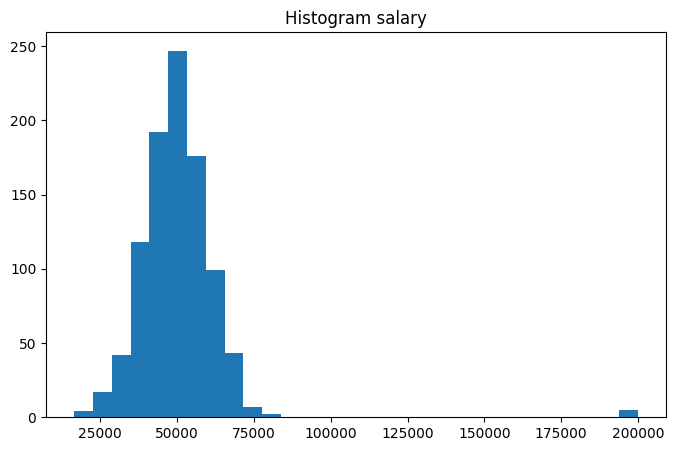

In [11]:
# Гистограмма
plt.hist(data["salary"].dropna(), bins=30)
plt.title("Histogram salary")
plt.show()


In [12]:
# Тест Шапиро-Уилка (для подвыборки)
sample = data["salary"].dropna().sample(500, random_state=42)

stat, p_value = stats.shapiro(sample)

print("Statistic:", stat)
print("p-value:", p_value)

if p_value > 0.05:
    print("Распределение похоже на нормальное")
else:
    print("Распределение отличается от нормального")


Statistic: 0.7780463337993276
p-value: 1.7380717147585704e-25
Распределение отличается от нормального


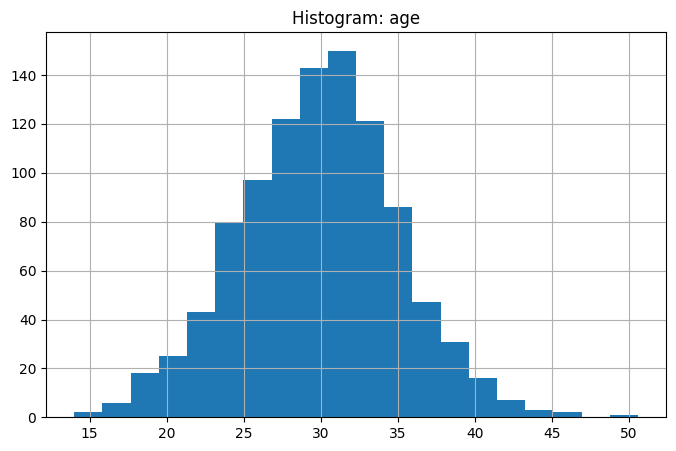

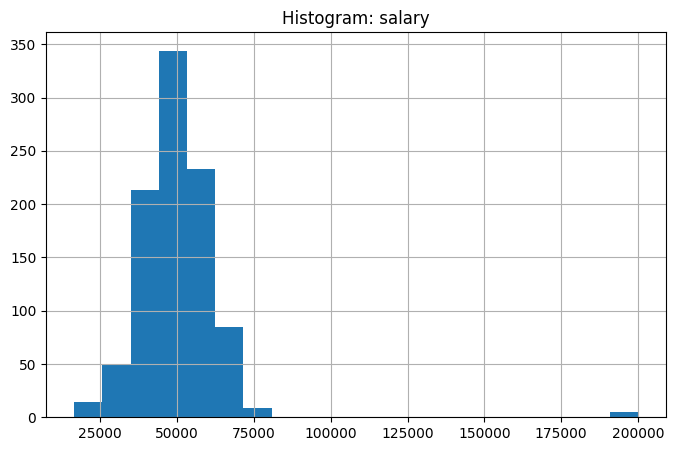

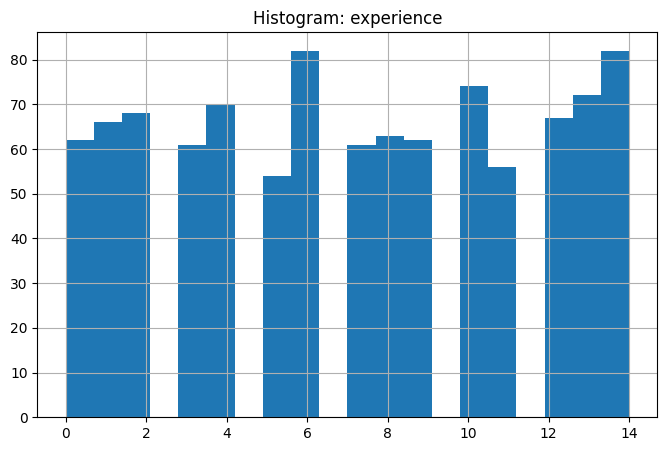

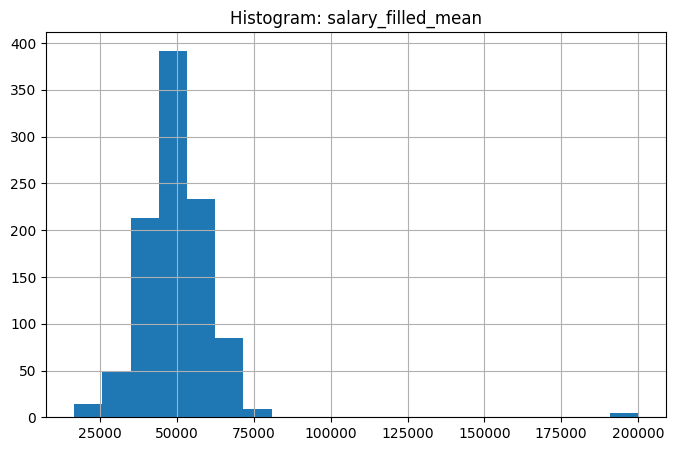

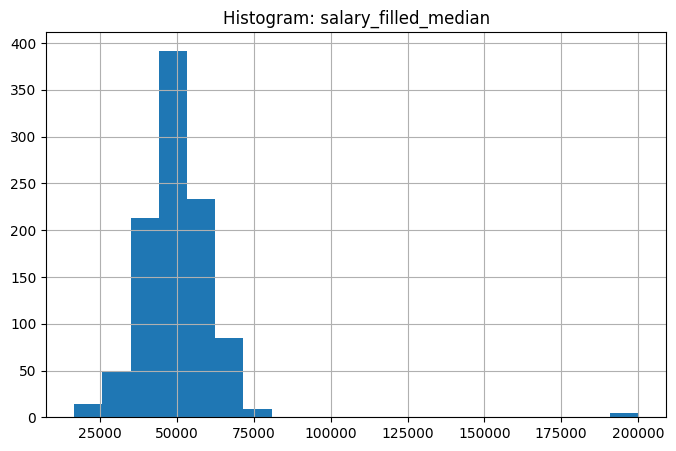

In [13]:

numeric_cols = data.select_dtypes(include='number').columns

for col in numeric_cols:
    data[col].hist(bins=20)
    plt.title(f"Histogram: {col}")
    plt.show()


## 6. Lambda-функции

In [31]:
def square(x):
    return x ** 2

square(5)

25

In [14]:
# Простая lambda
square = lambda x: x**2
square(5)


25

In [34]:
a = [1, 2, 3, 4, 5]

a_squared = list(map(lambda x: x**2, a))

a_squared

[1, 4, 9, 16, 25]

In [15]:
# Lambda в apply
data["age_category"] = data["age"].apply(
    lambda x: "young" if x < 30 else "adult"
)

data[["age", "age_category"]].head()


,age,age_category
0,19.385635,young
1,32.432323,adult
2,38.064300,adult
3,24.128318,young
4,41.129971,adult


In [16]:
# Lambda с несколькими условиями
data["exp_level"] = data["experience"].apply(
    lambda x: "junior" if x < 3 else ("middle" if x < 7 else "senior")
)

data[["experience", "exp_level"]].head()


,experience,exp_level
0,2,junior
1,2,junior
2,4,middle
3,11,senior
4,10,senior



## Проверка нормальности распределения

Добавим **QQ-plot** и **тест Шапиро–Уилка** для числовых признаков.

- QQ-plot показывает, насколько распределение похоже на нормальное (точки должны лежать примерно на прямой).
- Тест Шапиро–Уилка проверяет гипотезу нормальности:
  - H0: данные распределены нормально
  - если p-value < 0.05 → отклоняем H0 (распределение не нормальное)



## Распределения признаков (гистограммы)



## Корреляции между числовыми признаками


<Axes: >

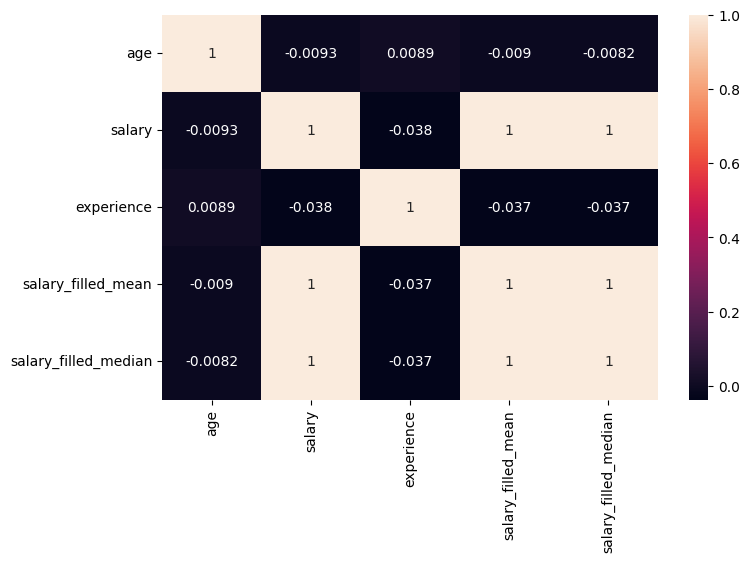

In [17]:
import seaborn


corr = data[numeric_cols].corr()

seaborn.heatmap(corr, annot=True)


#plt.imshow(corr)
#plt.colorbar()
#plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
#plt.yticks(range(len(numeric_cols)), numeric_cols)
#plt.title("Correlation matrix")
#plt
#plt.show()



## Анализ категориальных признаков


In [18]:

cat_cols = data.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n{col}")
    print("Уникальных значений:", data[col].nunique())
    print(data[col].value_counts().head(10))



age_category
Уникальных значений: 2
age_category
adult    503
young    497
Name: count, dtype: int64

exp_level
Уникальных значений: 3
exp_level
senior    537
middle    267
junior    196
Name: count, dtype: int64
